# Conos walkthrough: jointly analysing a panel of samples

**Conos** (*Clustering On Network of Samples*) analyses a *collection*
of single-cell samples **together**. Rather than merging all the cells
into one matrix, it aligns each pair of samples in a shared space and
stitches their neighbourhoods into a single weighted graph. On that
joint graph it then runs clustering, embedding, and differential
expression — so cells of the same type connect *across* samples while
each sample keeps its own structure.

We run the whole standard workflow on a panel of four bone-marrow (BM)
and cord-blood (CB) samples. When you need to control *how* the samples
are aligned (alignment spaces, strength, memory, multimodal data), see
the [advanced tutorial](conos-advanced.ipynb).

## The workflow at a glance

The entire standard analysis is just a handful of calls on the Conos
object. The rest of this walkthrough runs through each line, explains
the parameters, and shows what to look for in the output:

``` r
# one Pagoda2 object per sample: normalisation + PCA (+ a within-sample clustering)
samples <- lapply(panel, function(counts) Pagoda2$from(counts)$run())

con <- Conos$new(samples)
con$runGraph()           # align every pair of samples into one joint graph
con$runClustering()      # joint clusters (Leiden communities)
con$runEmbedding()       # joint 2-D embedding (UMAP)

con$plotGraph()                          # joint embedding: colour by cluster / sample / gene
con$plotPanel()                          # the same, faceted per sample
con$plotMarkerDotPlot()                  # top marker genes per cluster
con$propagateLabels(labels = cellannot)  # transfer annotations from one sample to the rest
```

## Contents

- [The workflow at a glance](#the-workflow-at-a-glance)
- [Loading the data](#loading-the-data)
- [Pre-processing each sample](#pre-processing-each-sample)
- [Constructing the Conos object](#constructing-the-conos-object)
- [Building the joint graph](#building-the-joint-graph)
- [Joint clustering](#joint-clustering)
- [The joint embedding](#the-joint-embedding)
- [Shared clusters vs per-sample
  clusters](#shared-clusters-vs-per-sample-clusters)
- [Are the samples well mixed?](#are-the-samples-well-mixed)
- [Cluster composition across
  samples](#cluster-composition-across-samples)
- [Looking at a gene](#looking-at-a-gene)
- [Marker genes](#marker-genes)
- [Transferring annotations between
  samples](#transferring-annotations-between-samples)
- [Markers of the transferred cell
  types](#markers-of-the-transferred-cell-types)

## Loading the data

A Conos panel is a **named list of per-sample objects** — one per
sample, each processed with
[pagoda2](https://github.com/kharchenkolab/pagoda2) (or Seurat). You
build one object per sample from its own count data; `Pagoda2$from()`
reads the formats you are most likely to have:

In [ ]:
library(pagoda2)

# a 10x CellRanger output folder (matrix.mtx / barcodes / features):
s1 <- Pagoda2$from10x("sample1/outs/filtered_feature_bc_matrix")

# a 10x HDF5 file:
s2 <- Pagoda2$from10xH5("sample2_filtered_feature_bc_matrix.h5")

# a counts matrix (genes x cells) you already have in memory:
s3 <- Pagoda2$from(my_counts_matrix)

For a runnable example we use a ready-made panel from the `conosPanel`
package
(`install.packages("conosPanel", repos = "https://kharchenkolab.github.io/drat/")`).
It is a named list of four sparse count matrices (genes × cells) — two
bone-marrow and two cord-blood samples:

In [ ]:
library(conos)
library(pagoda2)

panel <- conosPanel::panel
str(panel, 1)

List of 4
 $ MantonBM1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonBM2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots

**Cell names must be unique across the whole panel** — no two cells,
even in different samples, may share a name. Here each barcode is
already prefixed with its sample id, so there are no collisions:

In [ ]:
head(colnames(panel[[1]]), 3)

[1] "MantonBM1_HiSeq_1-TCTATTGGTCTCTCGT-1"
[2] "MantonBM1_HiSeq_1-GAATAAGTCACGCATA-1"
[3] "MantonBM1_HiSeq_1-ACACCGGTCTAACTTC-1"

[1] FALSE

To keep the tutorial fast we down-sample each matrix to a thousand
cells; in a real analysis you would use them all (and would first filter
out low-count / dying cells as part of standard QC).

In [ ]:
set.seed(1)
panel <- lapply(panel, function(m) m[, sample(ncol(m), 1000)])

## Pre-processing each sample

Each sample is turned into a `Pagoda2` object and processed **on its
own**: normalisation, a PCA reduction (which Conos will align on), a
within-sample kNN graph, and a within-sample clustering. A single
`run()` call does all of it, so the whole panel is one short `lapply`:

In [ ]:
samples <- lapply(panel, function(counts) {
  Pagoda2$from(counts, verbose = FALSE)$run(verbose = FALSE)
})

We now have a named list of `Pagoda2` objects — the starting point for
Conos:

In [ ]:
names(samples)

[1] "MantonBM1_HiSeq_1" "MantonBM2_HiSeq_1" "MantonCB1_HiSeq_1"
[4] "MantonCB2_HiSeq_1"

(If you prefer Seurat, pre-process with `basicSeuratProc()` instead and
pass the resulting list straight to `Conos$new()`; everything below is
identical.)

## Constructing the Conos object

`Conos$new()` simply collects the per-sample objects — nothing is
computed yet. `n.cores` controls the parallelism of the steps that
follow (graph construction in particular benefits from more cores):

In [ ]:
con <- Conos$new(samples, n.cores = 1)

## Building the joint graph

`runGraph()` is the heart of Conos. For **every pair** of samples it
projects the two into a shared space, finds mutual nearest neighbours
between them, and adds within-sample neighbours so that every cell is
connected — producing one joint graph spanning the whole panel.

The `space` argument chooses how each pair is matched. `"PCA"`
(reciprocal PCA, the default used here) is fast and robust and is the
right choice for most panels; `"CCA"` helps for very heterogeneous
panels; `"CPCA"` and `"genes"` are also available. The [advanced
tutorial](conos-advanced.ipynb) compares them.

In [ ]:
con$runGraph(k = 15, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)

## Joint clustering

Now detect cell clusters as **communities** on the joint graph (Leiden
by default). Because the graph spans all samples, each cluster is a
population defined *consistently* across the whole panel:

In [ ]:
con$runClustering(verbose = FALSE)

## The joint embedding

Compute a 2-D embedding of the joint graph (UMAP) so we can see it, then
colour it by the clusters:

In [ ]:
con$runEmbedding(method = "UMAP", min.visited.verts = 100, verbose = FALSE)

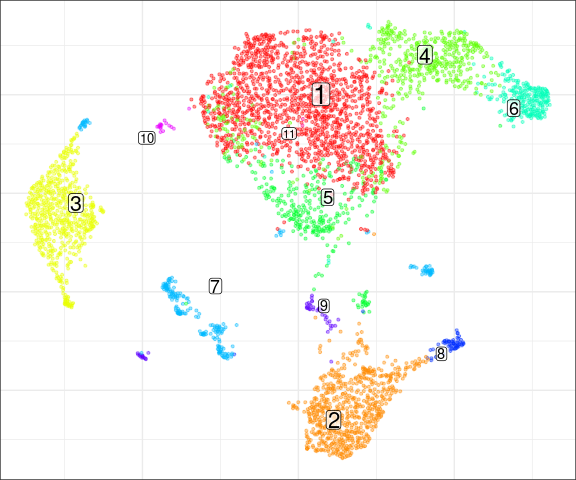

In [ ]:
con$plotGraph(clustering = "leiden")

Each blob is a cluster; neighbouring blobs are transcriptionally similar
populations.

## Shared clusters vs per-sample clusters

Why bother with a joint graph at all? Each sample was *also* clustered
on its own during pre-processing. Laid over the joint embedding, those
**independent** clusterings use a different, unrelated set of labels in
every sample — cluster “3” in one sample has nothing to do with cluster
“3” in another:

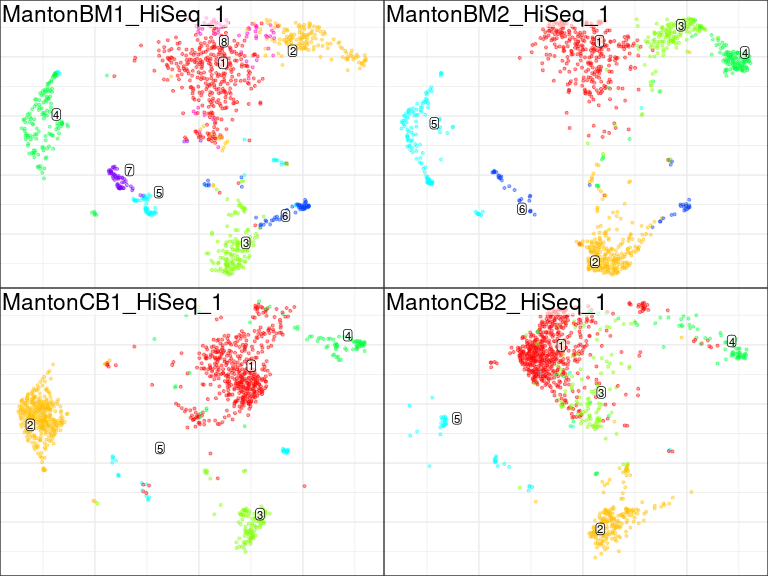

In [ ]:
con$plotPanel(clustering = "leiden", use.local.clusters = TRUE, use.common.embedding = TRUE, font.size = 3)

The **joint** clustering fixes exactly this. The same colours now mean
the same population in every sample, so a cluster present in several
samples is immediately recognisable as one shared cell type:

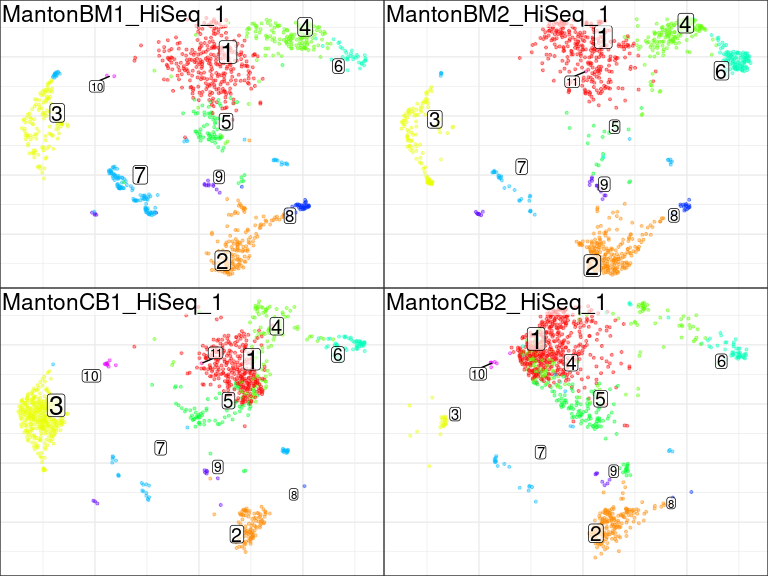

In [ ]:
con$plotPanel(clustering = "leiden", use.common.embedding = TRUE)

## Are the samples well mixed?

*The* question for any integration: do the samples **overlap** in the
joint embedding (good — the same cell types are aligned across samples)
or sit apart (under-correction, or genuinely distinct populations)?
Colour the *same* embedding by **sample**:

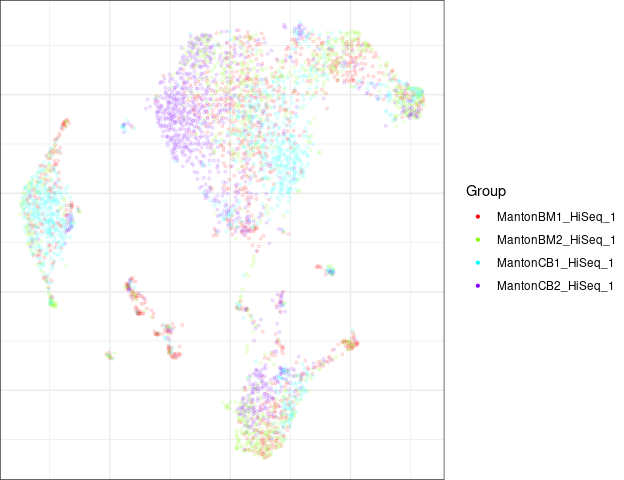

In [ ]:
con$plotGraph(color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

Cells from all four samples are interspersed within each region rather
than forming sample-specific islands, so the populations are well
aligned.

## Cluster composition across samples

`plotClusterBarplots()` shows what fraction of each cluster comes from
each sample — handy for spotting populations that are sample- or
condition-specific (here, differences between bone marrow and cord
blood):

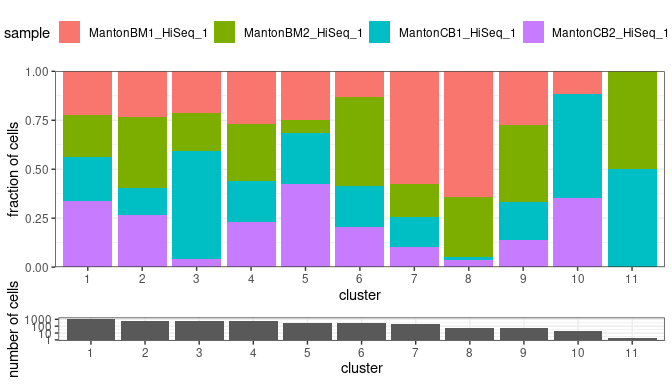

In [ ]:
plotClusterBarplots(con, clustering = "leiden", show.entropy = FALSE)

A bar split evenly across samples is a shared population; a bar
dominated by one or two samples flags a condition-specific one.

## Looking at a gene

You can paint any gene onto the joint embedding to see where it is
expressed — here *CD3E*, a pan-T-cell marker:

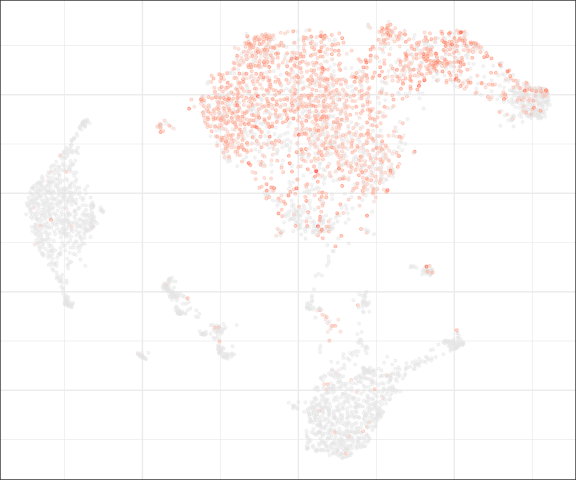

In [ ]:
con$plotGraph(gene = "CD3E")

The same gene, shown per sample on the common embedding, confirms the
pattern is consistent across the panel rather than driven by one sample:

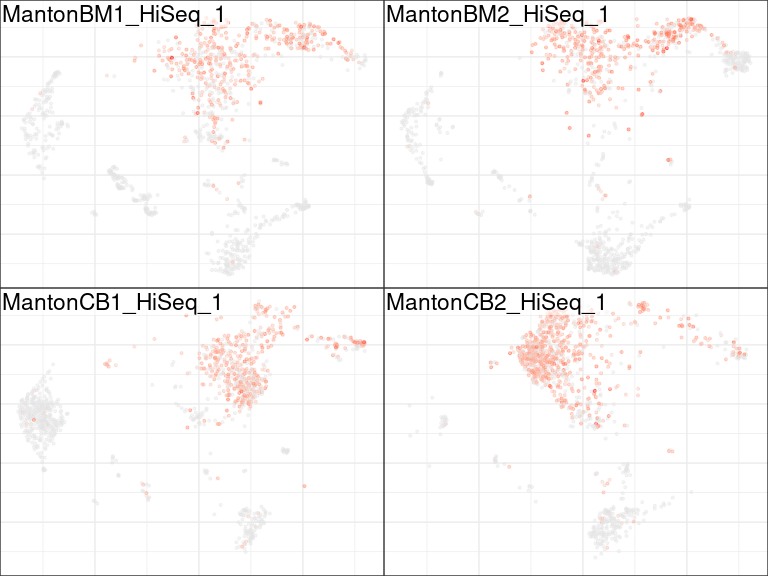

In [ ]:
con$plotPanel(gene = "CD3E", use.common.embedding = TRUE)

## Marker genes

`runMarkers()` finds genes differentially expressed between clusters,
and `plotMarkerDotPlot()` shows the top few **specific** markers per
cluster — dot **size** is the fraction of cells expressing the gene, dot
**colour** is the scaled mean expression:

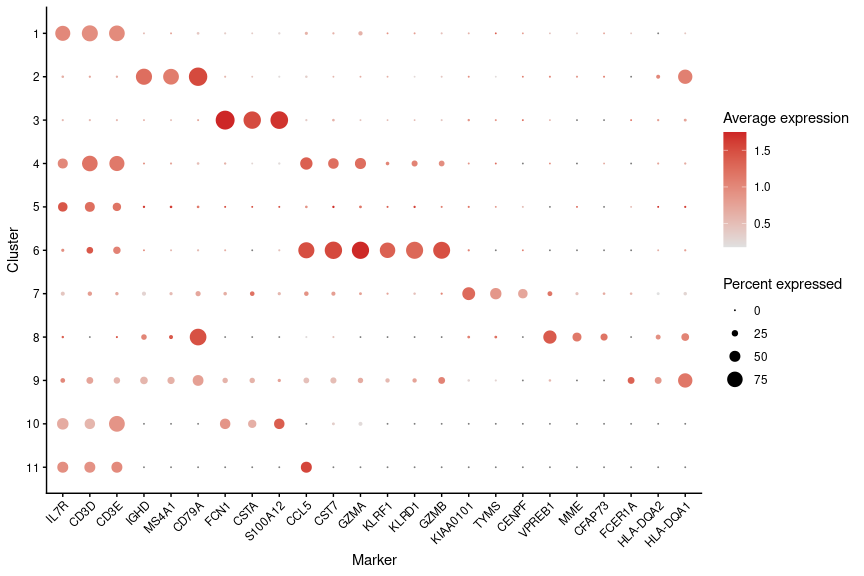

In [ ]:
con$plotMarkerDotPlot(n.genes.per.group = 3)

The diagonal pattern (each cluster lit up by its own genes) is what to
look for, and it lets you read off cell identities — e.g. the T-cell
(*CD3D/CD3E/IL7R*), B-cell (*MS4A1/CD79A*), monocyte (*FCN1/CSTA*) and
NK (*KLRF1/GZMB*) blocks.

## Transferring annotations between samples

A very common task: carry cell-type labels from one **annotated** sample
onto the rest of the panel. We load a real annotation of the first
bone-marrow sample (shipped with conos) — a named factor of cell types:

In [ ]:
cellannot <- read.table(file.path(find.package("conos"), "extdata", "cellannot.txt"),
                        header = FALSE, sep = "\t")
cellannot <- setNames(cellannot[, 2], cellannot[, 1])
head(cellannot, 3)

MantonBM1_HiSeq_1-TCACGAACATGGTCAT-1 MantonBM1_HiSeq_1-TGGCTGGTCCGGGTGT-1 
                        "T CD4-CD8-"                         "T CD4-CD8-" 
MantonBM1_HiSeq_1-AATCCAGAGTCGTTTG-1 
                       "progenitors" 

Per sample, the labels exist for only one sample; the other three are
unlabelled (shown faded):

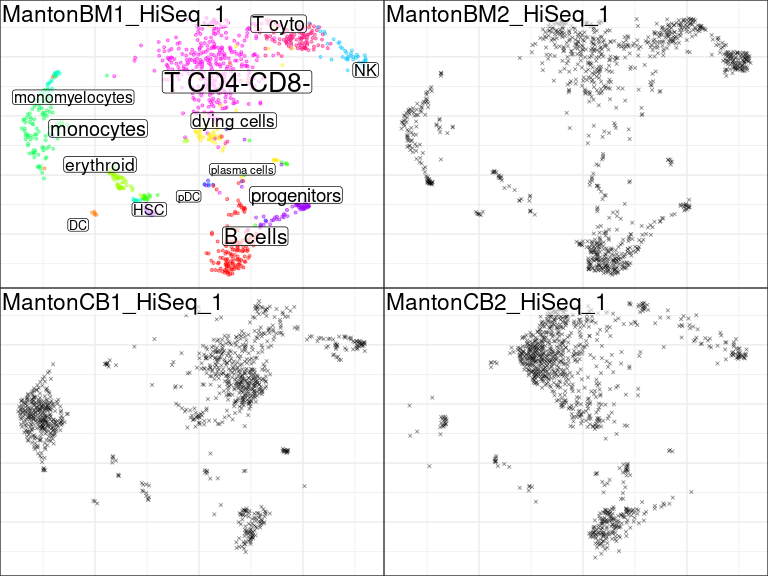

In [ ]:
con$plotPanel(groups = cellannot, use.common.embedding = TRUE)

`propagateLabels()` spreads those labels over the joint graph, returning
a transferred label **and** an uncertainty score for every cell:

In [ ]:
transfer <- con$propagateLabels(labels = cellannot, verbose = FALSE)

On the joint embedding, the cell types now cover all the cells — and
line up with the clusters we found independently:

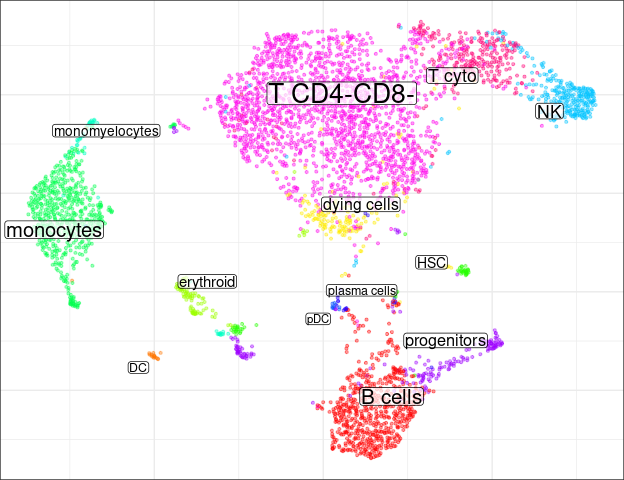

In [ ]:
con$plotGraph(groups = transfer$labels)

Faceting the transferred labels **by sample** shows the same cell types
recovered consistently in every sample, including the three that started
out unlabelled:

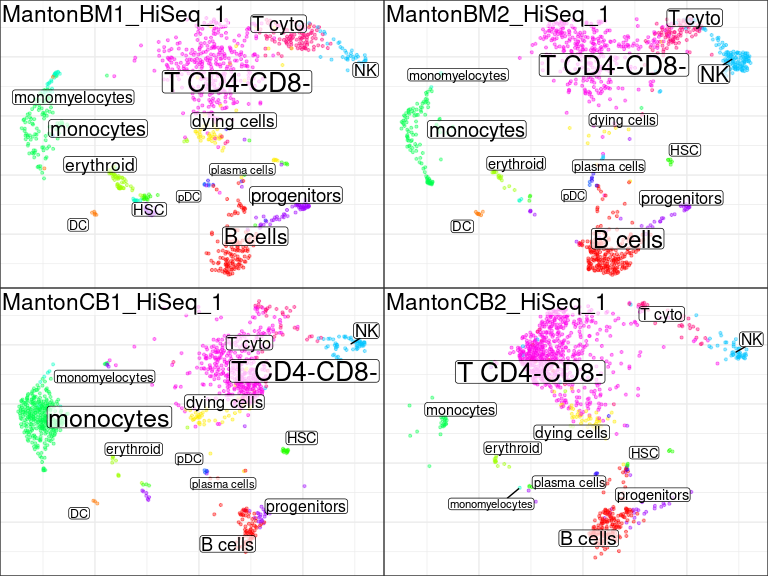

In [ ]:
con$plotPanel(groups = transfer$labels, use.common.embedding = TRUE, show.legend = FALSE)

`transfer$uncertainty` is a 0–1 score per cell (low = confident).
Painting it per sample shows *where* the transfer is trustworthy —
uncertainty rises at the boundaries between populations and in rare
types:

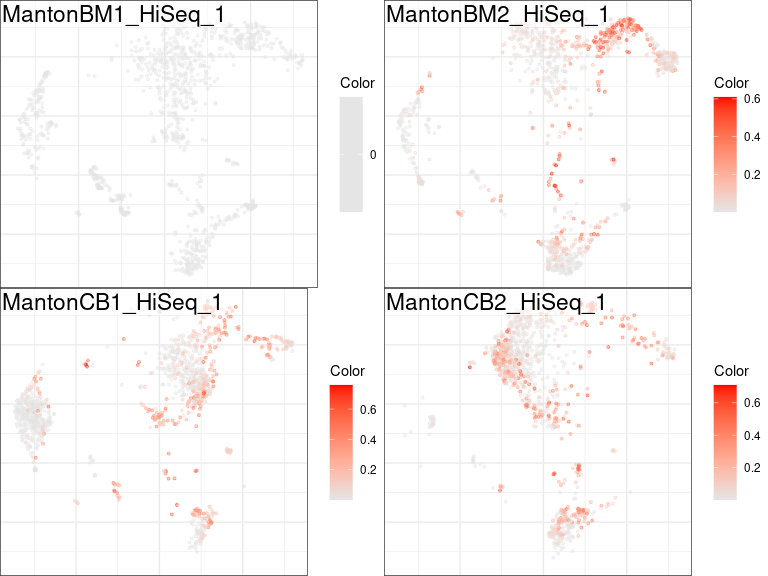

In [ ]:
con$plotPanel(colors = transfer$uncertainty, use.common.embedding = TRUE, show.legend = TRUE)

## Markers of the transferred cell types

Because the transferred labels are *named* cell types, marker detection
on them is directly interpretable. `runMarkers()` returns, per cell
type, a table of differentially expressed genes with effect size (`M`),
significance (`Z`), and — with `append.auc = TRUE` — discrimination and
specificity metrics:

In [ ]:
de <- con$runMarkers(groups = transfer$labels, append.auc = TRUE, verbose = FALSE)
head(de[["B cells"]][order(-de[["B cells"]]$AUC), c("Gene", "M", "Z", "AUC", "Specificity", "Precision")])

      Gene        M        Z       AUC Specificity Precision
3    CD79A 2.319533 15.55470 0.9064901   0.9174715 0.6606498
5 HLA-DPB1 2.109054 15.98568 0.8859074   0.8291027 0.4995678
4 HLA-DPA1 2.133263 15.92106 0.8758828   0.8309321 0.4956140
8     IGHD 2.511520 14.14275 0.8758243   0.9638243 0.7931034
2  HLA-DRA 1.952083 16.75669 0.8691466   0.7587641 0.4249292
9    MS4A1 2.461358 13.68987 0.8591863   0.9634599 0.7834179

The top B-cell markers are exactly the expected ones (*CD79A*, *MS4A1*,
*IGHD*, MHC-II genes). A dot plot across all the transferred types reads
as a clean marker map of the panel:

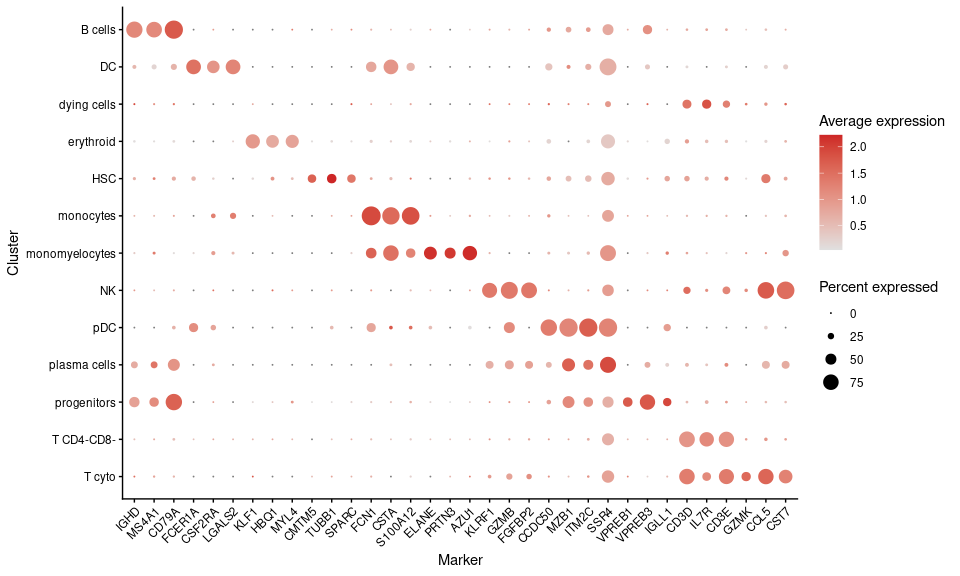

In [ ]:
con$plotMarkerDotPlot(groups = transfer$labels, n.genes.per.group = 3)

That is the whole standard workflow previewed at the top, now seen end
to end. To control *how* the samples are aligned — alignment space,
strength, memory, and multimodal data — continue to the [advanced
tutorial](conos-advanced.ipynb).